# Lunar Lander

This environment is a classic rocket trajectory optimization problem. The landing pad is always at coordinates (0,0). The state is an 8-dimensional vector: the coordinates of the lander in x & y, its linear velocities in x & y, its angle, its angular velocity, and two booleans that represent whether each leg is in contact with the ground or not.

There are four discrete actions available:<br>
- 0: do nothing<br>
- 1: fire left orientation engine<br>
- 2: fire main engine<br>
- 3: fire right orientation engine<br>

After every step a reward is granted. The total reward of an episode is the sum of the rewards for all the steps within that episode.

For each step, the reward:

- is increased/decreased the closer/further the lander is to the landing pad.

- is increased/decreased the slower/faster the lander is moving.

- is decreased the more the lander is tilted (angle not horizontal).

- is increased by 10 points for each leg that is in contact with the ground.

- is decreased by 0.03 points each frame a side engine is firing.

- is decreased by 0.3 points each frame the main engine is firing.

The episode receive an additional reward of -100 or +100 points for crashing or landing safely respectively.

An episode is considered a solution if it scores at least 200 points.


You can read more the LunarLander environment [here](https://gymnasium.farama.org/environments/box2d/lunar_lander/)

![LunarLander](https://gymnasium.farama.org/_images/lunar_lander.gif)

# Reinforce Algorithm (T2)

The On-policy/Off-policy separation is not the only big division in reinforcement learning algorithms. Another demarcation line often used to group RL algorithms is between value function algorithms and policy gradient ones. The first group contains the algorithms that look for an optimal policy by estimating the value function, the second group instead is made up of those algorithms that directly modify the policy based on the episodes return.

The policy gradient algorithms can be especially useful in situations in which the action space and the observation space are too large to make value function approximation computationally feasible. Instead of modeling each state, action pair one can try to modify the policy directly. REINFORCE is an example of such a technique.

It works by exploring different trajectories in the state, action space and calculating the return from these. If the return is high, we increase the chances of selecting the actions making up the trajectory, if it is low, we instead decrease them, therefore "reinforcing" the positive behaviour. Because we are sampling from the trajectory space and using the returns to get an estimate of the best actions, REINFORCE is considered a Monte Carlo method.


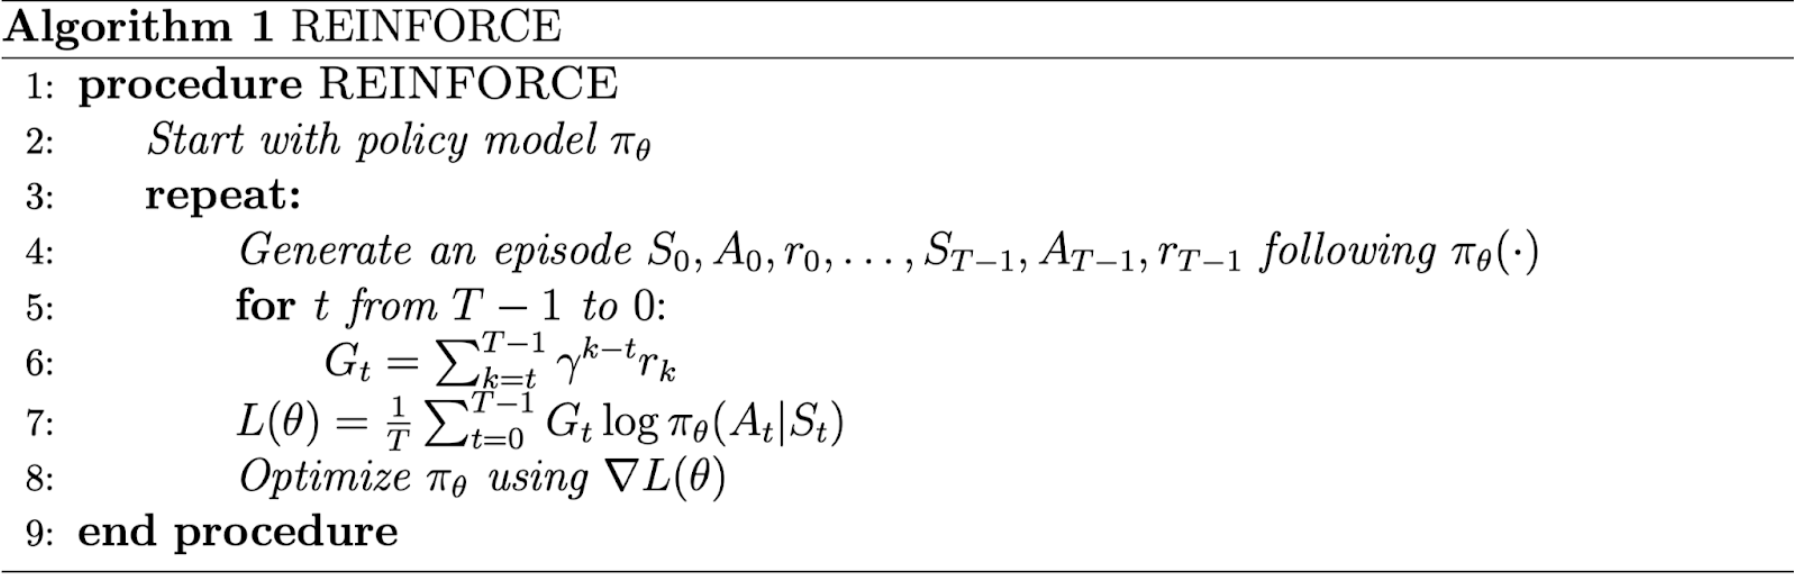


[Image Source](https://colab.research.google.com/github/huggingface/deep-rl-class/blob/master/notebooks/unit4/unit4.ipynb)

The main drawback from this kind of approach is the volatility inherent in the process. In value function methods like Q-Learning, the policy is updated at each step, therefore checking the goodness of our qvalue estimate for each action. Instead, policy gradient approaches are such that an action is judged by the return of the whole trajectory. A specific action from a good trajectory may actually have been a quite bad choice, but it is still reinforced. Similarly, a good action from a bad trajectory sees its probability of being chosen lowered. This usually means that with the same amount of data, gradient policy technique show more variable performances with respect to value function methods.

Several ways have been developed to counter this effect. Three basic interventions already can help a lot:


*   Reward-to-Go: In the REINFORCE objective function, the sum of the log-prob from each trajectories are multiplied for the total return of the episode. This means that each action is made responsible of the final episode outcome, independently of the actual credit. A better choice is to multiply the log-prob from step t for the sum of the rewards from that step onward, which better estimates the credit of each action.

$$∇_θ 𝔍(θ) ≈ ∑_t \left(\sum_{t' \geq t}r_{t'}\right)log(π_θ(a_t|s_t))$$

*   Discount Factor: The Reward-to-go may still be too much. An action at step 10 of a 300 steps trajectory is still linked to the reward more likely caused by later actions. To reduce this bias we can use a discount factor.

$$∇_θ 𝔍(θ) ≈ ∑_t \left(\sum_{t' \geq t} γ^{t'-t} r_{t'}\right)log(π_θ(a_t|s_t))$$

* Baseline: Every trajectory is valued on the base of the return obtained. If an environment expects positive rewards only, than the returns are always positive and even bad runs would imply the method trying to increase the actions probabilities. It makes more sense instead to compare the return from an episode to some sort of baseline, for example the average of the episodes or a moving average, so that the algorithms tries to improve over this average.


$$∇_θ 𝔍(θ) ≈ ∑_t \left(\sum_{t' \geq t} γ^{t'-t} r_{t'} - b(s_t)\right)log(π_θ(a_t|s_t)) $$

This relatively simple modifications allow for much better practical results.







In [ ]:
!pip install swig
!pip install "gymnasium[box2d]"

In [ ]:
import gymnasium as gym
import math
import random
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from collections import deque

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision.transforms as T
from torch.distributions import Categorical

In [ ]:
# if gpu is to be used
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
# Create the environment
env = gym.make("LunarLander-v3")

## Hyperparameters (T3)

Here the learning_rate is not the one from an update rule but the one from the neural network. We also have a droput_rate. Regarding the training process we can specify, as always, the number of episodes and the max_steps per episode. Finally, a gamma is defined for use as a discount factor for the second version of the finish_episode function.

In [ ]:
dropout_rate = 0.2
#neurons_exp = 7
learning_rate = 5e-4

max_steps = 1500
max_episodes = 3000

gamma = 0.99

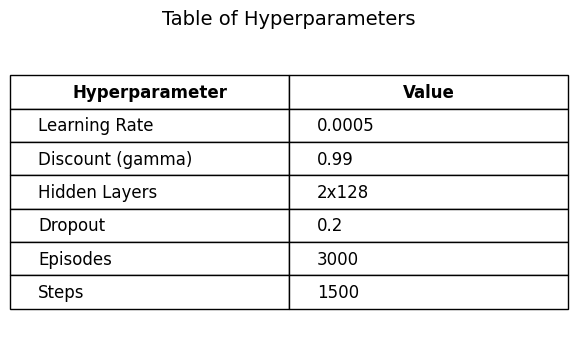

In [ ]:
def plot_table(params):
    table_data = [[k, v] for k, v in params.items()]

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.axis('off')

    table = ax.table(cellText=table_data,
                     colLabels=['Hyperparameter', 'Value'],
                     loc='center',
                     cellLoc='left')

    table.auto_set_font_size(False)
    table.set_fontsize(12)
    table.scale(1.2, 2.0)

    for (row, col), cell in table.get_celld().items():
        if row == 0:
            cell.set_text_props(weight='bold')

    plt.title("Table of Hyperparameters", fontsize=14, pad=10)
    plt.show()

params = {
    "Learning Rate": learning_rate,
    "Discount (gamma)": gamma,
    "Hidden Layers": "2x128",
    "Dropout": dropout_rate,
    "Episodes": max_episodes,
    "Steps": max_steps
}

plot_table(params)

## Policy Network (T1)

The idea behind Gradient Policy algorithms can be declined in many different ways. With continuous, complex observation spaces, one usually takes advantage of a neural network to model the action probabilities, and therefore the policy, for each given state. As in the previous exercise, we are using the Lunar Lander v3 environment again, and therefore we have an 8-dim state space and a 4-dim action space. We use the same 2 hidden layers MLP, adding a softmax activation on the output layer as in this case we don't want the qvalues but the actions' probabilities instead.

Another difference with the MLP used in the DQN exercise, is the use of dropout. This regularization technique can be useful in REINFORCE algorithms as they modify the weights one time per episode, and it's not rare for this kind of algorithms to overfit over a particularly good run and lose generalization power. A moderate dropout rate can help with this.

Using a similar architecture to the DQN exercise allows for a more direct comparison between the two methods.

In [ ]:
class Policy(nn.Module):
    def __init__(self, n_observations, n_actions):
        super(Policy, self).__init__()
        self.layer1 = nn.Linear(n_observations, 128)
        self.layer2 = nn.Linear(128, 128)
        self.dropout = nn.Dropout(p=dropout_rate)
        self.layer3 = nn.Linear(128, n_actions)

    def forward(self, x):
        x = F.relu(self.layer1(x))
        x = F.relu(self.layer2(x))
        x = self.dropout(x)
        action_probs = self.layer3(x)
        return F.softmax(action_probs, dim=1)

## Action Selection (T1)

In [ ]:
policy = Policy(env.observation_space.shape[0], env.action_space.n).to(device)
optimizer = optim.Adam(policy.parameters(), lr=learning_rate)

def select_action(state):
    state = torch.from_numpy(state).float().unsqueeze(0).to(device)
    probs = policy(state)
    distr = Categorical(probs)
    #The action is chosen by sampling from the distribution defined with the predicted action probabilities
    action = distr.sample()
    return action.item(), distr.log_prob(action)

## Policy Gradient Logic (T1)

In [ ]:
def finish_episode (saved_log_probs, rewards):
  R = sum(rewards)
  policy_loss = []

  for log_prob in saved_log_probs:
    policy_loss.append(-log_prob*R)

  optimizer.zero_grad()
  loss = torch.stack(policy_loss).sum()
  loss.backward()
  optimizer.step()

## Policy Gradient with Variance Reduction Techniques (T1)

In [ ]:
def finish_episode_variance_reduction(saved_log_probs, rewards, running_return, gamma=gamma):
    R = 0
    policy_loss = []
    returns = deque()

    for r in rewards[::-1]:
        R = r + gamma * R #Discounting the subsequent rewards to reduce bias
                          #and taking into considerations only the rewards after step t
        returns.appendleft(R)

    returns = torch.tensor(returns)
    advantages = returns - running_return #Aggiungiamo la moving average come baseline

    for log_prob, advantage in zip(saved_log_probs, advantages):
        policy_loss.append(-log_prob * advantage)

    optimizer.zero_grad()
    loss = torch.cat(policy_loss).sum()
    loss.backward()
    optimizer.step()

## Training (T1)

In [ ]:
running_return = -50 #Coherent with first runs
returns_list = []

for episode in range(max_episodes):
    state, _ = env.reset()
    saved_log_probs = []
    rewards = []

    for t in range(max_steps):
        action, log_prob = select_action(state)
        state, reward, terminated, truncated, _ = env.step(action)

        saved_log_probs.append(log_prob)
        rewards.append(reward)

        if terminated or truncated:
            break
    finish_episode(saved_log_probs, rewards)

    ep_return = sum(rewards)
    returns_list.append(ep_return)
    running_return = 0.05 * ep_return + (1 - 0.05) * running_return

    if episode % 50 == 0:
        print(f'Episode {episode}\tLast reward: {ep_return:.2f}\tAverage reward: {running_return:.2f}')

Episode 0	Last reward: -422.92	Average reward: -68.65
Episode 50	Last reward: -118.99	Average reward: -170.36
Episode 100	Last reward: -164.49	Average reward: -149.22
Episode 150	Last reward: -112.37	Average reward: -170.01
Episode 200	Last reward: -305.43	Average reward: -218.85
Episode 250	Last reward: -145.98	Average reward: -187.01
Episode 300	Last reward: -119.43	Average reward: -143.09
Episode 350	Last reward: -104.95	Average reward: -154.72
Episode 400	Last reward: -92.96	Average reward: -132.21
Episode 450	Last reward: -323.61	Average reward: -175.11
Episode 500	Last reward: -153.46	Average reward: -150.15
Episode 550	Last reward: -138.91	Average reward: -118.70
Episode 600	Last reward: -228.65	Average reward: -128.79
Episode 650	Last reward: -132.70	Average reward: -132.13
Episode 700	Last reward: -136.82	Average reward: -122.33
Episode 750	Last reward: -81.32	Average reward: -156.68
Episode 800	Last reward: -124.46	Average reward: -146.81
Episode 850	Last reward: -150.44	Aver

In [ ]:
running_return = -50 #Coherent with first runs
returns_list_variance_reduction = []

for episode in range(max_episodes):
    state, _ = env.reset()
    saved_log_probs = []
    rewards = []

    for t in range(max_steps):
        action, log_prob = select_action(state)
        state, reward, terminated, truncated, _ = env.step(action)

        saved_log_probs.append(log_prob)
        rewards.append(reward)

        if terminated or truncated:
            break
    #finish_episode(saved_log_probs, rewards)
    finish_episode_variance_reduction(saved_log_probs, rewards, running_return)

    ep_return = sum(rewards)
    returns_list_variance_reduction.append(ep_return)
    running_return = 0.05 * ep_return + (1 - 0.05) * running_return

    if episode % 50 == 0:
        print(f'Episode {episode}\tLast reward: {ep_return:.2f}\tAverage reward: {running_return:.2f}')

Episode 0	Last reward: -95.53	Average reward: -52.28
Episode 50	Last reward: -126.25	Average reward: -90.16
Episode 100	Last reward: -105.79	Average reward: -91.12
Episode 150	Last reward: -97.72	Average reward: -87.80
Episode 200	Last reward: -93.49	Average reward: -80.84
Episode 250	Last reward: -61.92	Average reward: -75.87
Episode 300	Last reward: -135.95	Average reward: -62.09
Episode 350	Last reward: -6.70	Average reward: -68.28
Episode 400	Last reward: -164.37	Average reward: -68.58
Episode 450	Last reward: -125.95	Average reward: -59.13
Episode 500	Last reward: -56.19	Average reward: -62.27
Episode 550	Last reward: -35.30	Average reward: -58.87
Episode 600	Last reward: 6.58	Average reward: -57.74
Episode 650	Last reward: -82.14	Average reward: -37.79
Episode 700	Last reward: -10.77	Average reward: -37.75
Episode 750	Last reward: 38.87	Average reward: -46.34
Episode 800	Last reward: -12.41	Average reward: -13.48
Episode 850	Last reward: -37.11	Average reward: -0.88
Episode 900	L

# Visualization (T3)

To check the model performances we plot the reward per episode and the moving average. The REINFORCE without variance reductions isn't really able to learn much, even after having played with the parameters and having trained the model for 3000 episodes. When the Reward-to-go, discount factor and moving average baseline are added, the situation changes drastically. After a few hundreds episodes of exploration, the model is now able to find better and better policies and the moving average improves to 150+.

One evident problem however remains, there is a strong variance in the rewards obtained. Variance reduction techniques are intended to reduce the gradient variance, making training stable and effective, but this also means that the algorithm explores many more scenarios leading to stronger rewards variance. The final effect is that after 3000 episodes the model sometimes achieves very nice runs, with high rewards in excess of 300, but often it also crashes the lander and we get -200,-300 returns. This is a kind of behaviour often seen with REINFORCE and other gradient policy algorithms applied in their most basilar form.

Another phenomenon which is quite evident in some run is what is usually termed a catastrophic forgetting. After having improved a lot we see an interval of runs in which the average becomes suddenly much lower, the model has encountered a few bad runs which have quickly modified the policy so as to forget some of the good choices it was making before. Often the model is able to get the average back up but this adds to the noise and makes it unreliable. Again, DQN is not only much more data efficient in this environment, but also much more stable.

In [ ]:
def plot(returns, title):
    plt.figure(figsize=(12, 6))

    plt.plot(returns, label='Return per Episode', color='blue', alpha=0.5)

    window_size = 30
    if len(returns) >= window_size:
        moving_avg = np.convolve(returns, np.ones(window_size)/window_size, mode='valid')
        x_axis = np.arange(window_size - 1, len(returns))
        plt.plot(x_axis, moving_avg, label=f'Moving Average ({window_size} eps)',
                 color='firebrick', linewidth=2.5)

    #THe Lunar Lander environment is considered solver if the episode reward si above 200, so we add a threshold
    plt.axhline(y=200, color='green', linestyle='--', label='Solved (Reward = 200)')

    plt.title(title)
    plt.xlabel('Episode')
    plt.ylabel('Return')
    plt.legend(loc='center left')
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.tight_layout()
    plt.show()

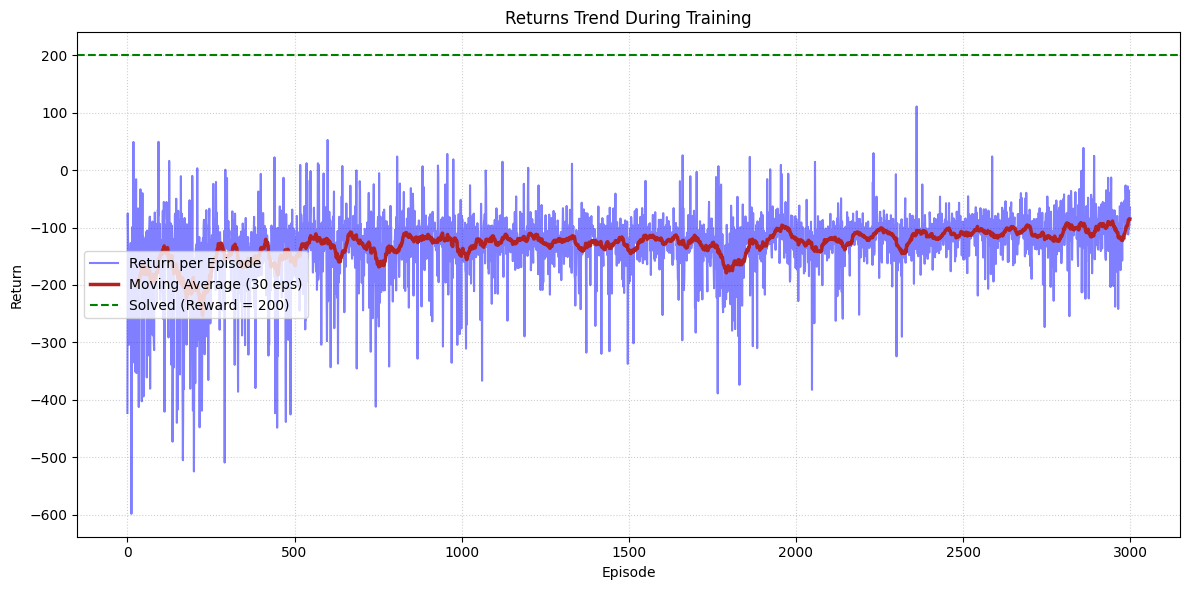

In [ ]:
plot(returns_list, title = 'Returns Trend During Training')

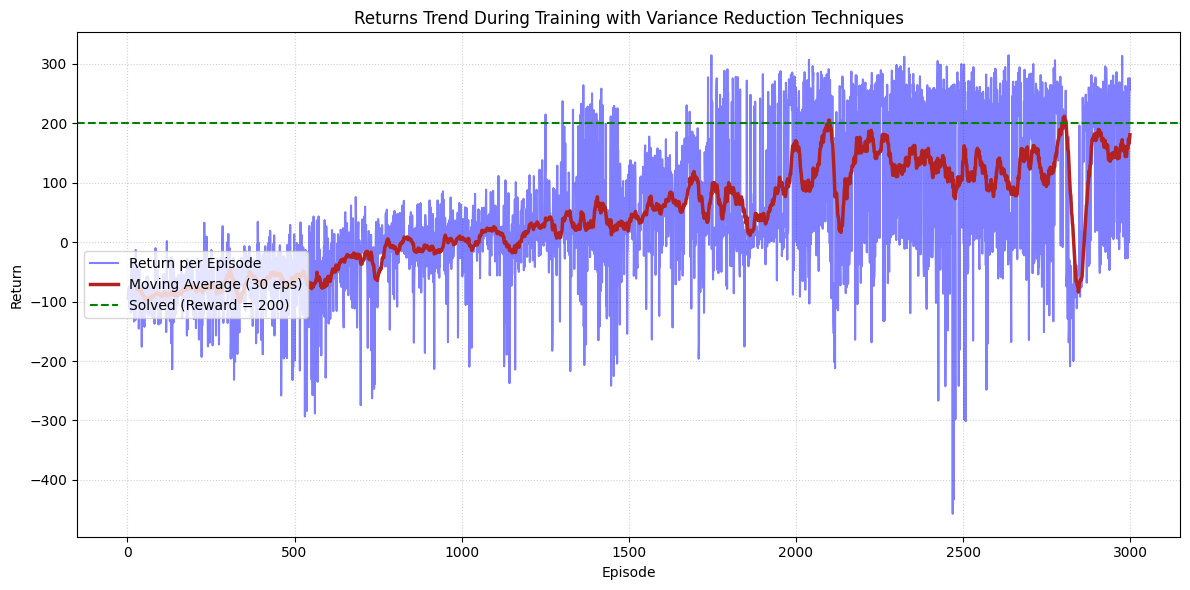

In [ ]:
plot(returns_list_variance_reduction, title = 'Returns Trend During Training with Variance Reduction Techniques')

#Parameters Tested

In this exercise, due to the long training time, parameters optimization was done manually. A few values of the learning rate were tried (1e-2, 1e-3, 1e-4, 5e-4). With 1e-2, the model wasn't able to learn anything, even the variance reduction techniques in place. Lower values of lr showed instead improved, but going too low (1e-4) also showed diminishing performances. 1e-3 and 5e-4 showed the strongest learning.

The dropout_rate tested were 0.2, 0.5 and 0.6, with differences between each not particularly significative.

The number of episodes was also modified, passing from 100 to 1000 to 3000. With 1000 episodes or less the models wasn't really able to learn much. After 3000 episodes it is evident that the variance reduction model was getting better at the task, but still well below an average return of 200, considered a success in Lunar Lander. This is interesting as we are training for 10 times the episode we used for the DQN algorithm, which with only 300 episodes learned the environment well enough to score an average of over 200. DQN seems to be a much better choice in this case, as the environment isn't complex enough the justify the use of a gradient policy network.